# Exploration données rayonnement solaire
* Source des données : [odre.opendatasoft.com](https://odre.opendatasoft.com/explore/dataset/rayonnement-solaire-vitesse-vent-tri-horaires-regionaux/information/?disjunctive.region)

In [1]:
# Import des modules utilisés
import requests
import pandas as pd
import time

In [2]:
# Définition de l'url qui contient les données
# Formats disponibles : csv, json, parquet, etc

# json
#url = 'https://odre.opendatasoft.com/api/explore/v2.1/catalog/datasets/rayonnement-solaire-vitesse-vent-tri-horaires-regionaux/exports/json'

# parquet
url = 'https://odre.opendatasoft.com/api/explore/v2.1/catalog/datasets/rayonnement-solaire-vitesse-vent-tri-horaires-regionaux/exports/parquet'

In [3]:
# Code pour parquet
from io import BytesIO

start_time = time.time()

# Récupération des données
response = requests.get(url)

# Vérification de la bonne récupération
if response.status_code == 200:
    # Permet de lire le fichier
    file_content = BytesIO(response.content)
    print("Données disponibles !\n")
    # Création du jeu de données
    df = pd.read_parquet(file_content)
    print(f"Le dataframe contient {df.shape[0]} lignes et {df.shape[1]} colonnes.")
else:
    print(f"Erreur: {response.status_code}")

end_time = time.time()
execution_time = end_time - start_time
print(f"Temps d'exécution : {execution_time:.2f} seconds")

Données disponibles !

Le dataframe contient 342575 lignes et 5 colonnes.
Temps d'exécution : 142.30 seconds


In [4]:
df.head()

,date,code_insee_region,region,uv100,ssrd03h
0,2016-10-11 03:00:00+00:00,84,Auvergne-Rhône-Alpes,4.10,0.00
1,2016-10-11 03:00:00+00:00,93,Provence-Alpes-Côte d'Azur,7.56,0.00
2,2016-10-11 06:00:00+00:00,27,Bourgogne-Franche-Comté,4.52,0.11
3,2016-10-11 06:00:00+00:00,84,Auvergne-Rhône-Alpes,4.05,0.07
4,2016-10-11 06:00:00+00:00,76,Occitanie,7.42,0.00


Colonne uv100 = rayonnement solaire global (W/m2)

In [5]:
# Extraction de l'année, et des valeurs uniques
df['date'].dt.year.unique()

array([2016, 2019, 2018, 2017, 2020, 2021, 2022, 2023, 2024, 2025])

## Filtre sur le département 93 et année 2025

In [6]:
# Définitions des filtres

# Sélection du département 93
cond_93 = df['code_insee_region']=='93'

# Sélection de l'année 2025
cond_2025 = df['date'].dt.year==2025

In [7]:
# Filtre du df
df_93_2025 = df[cond_93 & cond_2025]
df_93_2025.shape

(249, 5)

In [8]:
df_93_2025.head()

,date,code_insee_region,region,uv100,ssrd03h
339350,2025-01-01 00:00:00+00:00,93,Provence-Alpes-Côte d'Azur,4.14,0.00
339352,2025-01-09 15:00:00+00:00,93,Provence-Alpes-Côte d'Azur,6.42,201.19
339362,2025-01-10 09:00:00+00:00,93,Provence-Alpes-Côte d'Azur,6.29,105.52
339368,2025-01-10 12:00:00+00:00,93,Provence-Alpes-Côte d'Azur,6.14,246.38
339375,2025-01-10 18:00:00+00:00,93,Provence-Alpes-Côte d'Azur,6.43,70.53


In [9]:
# Tri par date/heure croissantes
df_93_2025_sorted = df_93_2025.sort_values(by='date')
df_93_2025_sorted.head(n=10)

,date,code_insee_region,region,uv100,ssrd03h
339350,2025-01-01 00:00:00+00:00,93,Provence-Alpes-Côte d'Azur,4.14,0.00
341712,2025-01-01 03:00:00+00:00,93,Provence-Alpes-Côte d'Azur,5.71,0.00
341779,2025-01-01 06:00:00+00:00,93,Provence-Alpes-Côte d'Azur,5.21,0.00
341781,2025-01-01 09:00:00+00:00,93,Provence-Alpes-Côte d'Azur,5.12,47.08
341783,2025-01-01 12:00:00+00:00,93,Provence-Alpes-Côte d'Azur,5.79,292.18
341787,2025-01-01 15:00:00+00:00,93,Provence-Alpes-Côte d'Azur,6.15,262.98
340052,2025-01-01 18:00:00+00:00,93,Provence-Alpes-Côte d'Azur,5.51,18.56
341726,2025-01-01 21:00:00+00:00,93,Provence-Alpes-Côte d'Azur,5.24,0.00
342230,2025-01-02 00:00:00+00:00,93,Provence-Alpes-Côte d'Azur,4.95,0.00
341730,2025-01-02 03:00:00+00:00,93,Provence-Alpes-Côte d'Azur,5.19,0.00


In [10]:
# TODO : à adapter si besoin, si utile

# Catégorisation des moments de la journée
def categorize_time_of_day(hour):
    if 6 <= hour < 12:
        return 'Matin'
    elif 12 <= hour < 15:
        return 'Midi'
    elif 15 <= hour < 18:
        return 'Après-midi'
    elif 18 <= hour < 22:
        return 'Soir'
    else:
        return 'Nuit'

# Application au df
df_93_2025_sorted['time_of_day'] = (
    df_93_2025_sorted['date'].dt.hour.apply(categorize_time_of_day))

In [11]:
# Pour visualisation
import matplotlib.pyplot as plt
import seaborn as sns

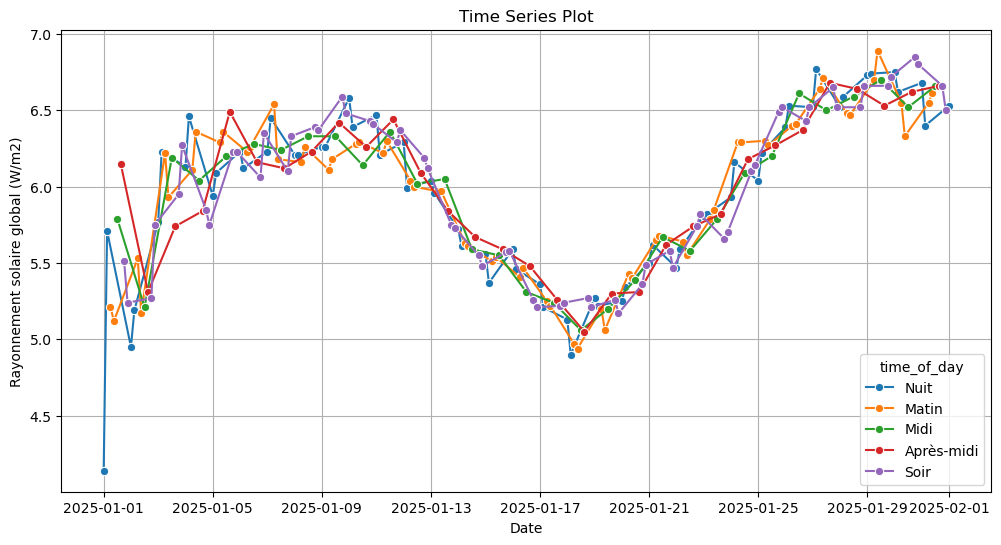

In [12]:
# Plotting the time series
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_93_2025_sorted, x='date', y='uv100',
             hue='time_of_day', marker='o')
plt.title('Time Series Plot')
plt.xlabel('Date')
plt.ylabel('Rayonnement solaire global (W/m2)')
plt.grid(True)
plt.show()

# Exploration du portail Meteo France
* Source des données : [portail-api.meteofrance.fr](https://portail-api.meteofrance.fr/web/fr/)

## Source données d'observation
* Lien de l'API utilisée : [DonneesPubliquesObservation](https://portail-api.meteofrance.fr/web/fr/api/DonneesPubliquesObservation)

### Analyse des stations

In [13]:
# Import des modules utilisés
import requests
import pandas as pd
from io import BytesIO

In [14]:
# Commencer par générer le OAuth token sur le site Meteo France
# A remplacer manuellement, ou récupérer via secrets
oauth_token = '...'

# Définition de l'url qui contient les données
url = 'https://public-api.meteofrance.fr/public/DPObs/v1/liste-stations'

# Ajout dans le header
headers = {
    'Authorization': f'Bearer {oauth_token}'
}

In [15]:
# Récupération des données
response = requests.get(url, headers=headers)

# Vérification de la bonne récupération
if response.status_code == 200:
    # S'assurer que c'est du text/plain
    # Si c'est JSON, probablement qu'il y a une erreur d'authentification (token incorrect/plus valide)
    if 'text/plain' in response.headers['Content-Type']:
        file_content = BytesIO(response.content)
        print("Données disponibles !\n")
        # Création du jeu de données
        df = pd.read_csv(file_content, delimiter=';', encoding='ISO-8859-1')
        print(f"Le dataframe contient {df.shape[0]} lignes et {df.shape[1]} colonnes.")
    else:
        print("Vérifier le token d'authentification")
else:
    print(f"Erreur: {response.status_code}")

Données disponibles !

Le dataframe contient 2130 lignes et 8 colonnes.


In [16]:
df.head()

,Id_station,Id_omm,Nom_usuel,Latitude,Longitude,Altitude,Date_ouverture,Pack
0,1014002,NaN,ARBENT,46.278167,5.669000,534,2003-10-01,RADOME
1,1027003,NaN,BALAN_AERO,45.833000,5.106667,196,2014-05-26,ETENDU
2,1034004,NaN,BELLEY,45.769333,5.688000,330,2001-09-13,RADOME
3,1064001,NaN,VERIZIEU,45.777167,5.487167,281,2015-01-01,ETENDU
4,1071001,NaN,CESSY,46.310333,6.080333,507,2002-05-01,RADOME


D'après la doc, il semblerait que l'identifiant de la station soit codé d'après la nomenclature suivante : 8 chiffres selon DDCCCNNN = insee de la commune (DD département, CCC n° de la commune dans le département et NNN n° de la station dans la commune).

In [17]:
# D'abord, convertir la colonne en text
df['Id_station'] = df['Id_station'].astype(str)

# Puis remplir sur 8 caractères
df['Id_station'] = df['Id_station'].str.pad(width=8, side='left', fillchar='0')

In [18]:
# Enfin, extraire le département (2 caractères à gauche)
df['dpt_num'] = df['Id_station'].str[:2]
df.head()

,Id_station,Id_omm,Nom_usuel,Latitude,Longitude,Altitude,Date_ouverture,Pack,dpt_num
0,01014002,NaN,ARBENT,46.278167,5.669000,534,2003-10-01,RADOME,01
1,01027003,NaN,BALAN_AERO,45.833000,5.106667,196,2014-05-26,ETENDU,01
2,01034004,NaN,BELLEY,45.769333,5.688000,330,2001-09-13,RADOME,01
3,01064001,NaN,VERIZIEU,45.777167,5.487167,281,2015-01-01,ETENDU,01
4,01071001,NaN,CESSY,46.310333,6.080333,507,2002-05-01,RADOME,01


In [22]:
# Département uniques
df['dpt_num'].unique()

array(['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11',
       '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22',
       '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33',
       '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44',
       '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55',
       '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66',
       '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77',
       '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88',
       '89', '90', '91', '92', '93', '94', '95', '97', '98'], dtype=object)

In [24]:
# Nombre de stations par département
nb_stations_par_dpt = (
    df.groupby('dpt_num')['Id_station']
    .nunique()
    .reset_index())
nb_stations_par_dpt

,dpt_num,Id_station
0,01,15
1,02,13
2,03,22
3,04,20
4,05,28
...,...,...
92,93,1
93,94,1
94,95,6
95,97,200


In [20]:
# Sélection des stations du 93
df[df['dpt_num']=='93']

# Une seule station pour le 93

,Id_station,Id_omm,Nom_usuel,Latitude,Longitude,Altitude,Date_ouverture,Pack,dpt_num
1808,93050001,NaN,NEUILLY-SUR-M.,48.859833,2.546333,30,1896-09-01,ETENDU,93


### Analyse des données par station

In [26]:
# Définition de l'id de la station (cf ci-dessus)
id_sta = '93050001'

# Date des mesures souhaitées (ex: 1er Jan 2025)
dt_sta = '2025-01-01'

In [27]:
# Définition de l'url qui contient les données
# Exemple avec la station ci-dessus (93050001), à la date du 01/01/2025 à minuit
url = f'https://public-api.meteofrance.fr/public/DPObs/v1/station/horaire?id_station={id_sta}&date={dt_sta}T00%3A00%3A00Z&format=json'

# OAuth token (même que défini au début du notebook)
#oauth_token = '...'

# Ajout dans le header
headers = {
    'Authorization': f'Bearer {oauth_token}'
}

In [29]:
# Récupération des données
response = requests.get(url, headers=headers)

# Vérification de la bonne récupération
if response.status_code == 200:
    # TODO : implémenter check si token non valide
    data = response.json()
    print("Données disponibles !\n")
    # Création du jeu de données
    df = pd.DataFrame(data)
    print(f"Le dataframe contient {df.shape[0]} lignes et {df.shape[1]} colonnes.")
else:
    print(f"Erreur: {response.status_code}")

Données disponibles !

Le dataframe contient 1 lignes et 32 colonnes.


In [30]:
pd.set_option("display.max_columns", None)  # Montre toutes les colonnes
df.head()

,lat,lon,geo_id_insee,reference_time,insert_time,validity_time,t,td,tx,tn,u,ux,un,dd,ff,dxy,fxy,dxi,fxi,rr1,t_10,t_20,t_50,t_100,vv,etat_sol,sss,n,insolh,ray_glo01,pres,pmer
0,48.859833,2.546333,93050001,2025-02-19T10:10:09Z,2025-02-19T10:03:33Z,2025-02-19T10:00:00Z,278.85,None,278.85,276.35,None,None,None,None,None,None,None,None,None,0.0,None,None,None,None,None,None,None,None,None,None,None,None


## Source données climatologiques
* Lien de l'API utilisée : [DonneesPubliquesClimatologie](https://portail-api.meteofrance.fr/web/fr/api/DonneesPubliquesClimatologie)

### Analyse des stations
* Semble fonctionner avec tous les départements, y compris outre mer

In [31]:
# Commencer par générer le OAuth token sur le site Meteo France
# A remplacer manuellement, ou récupérer via secrets
oauth_token = '...'

# Département pour lequel récupérer les données
dpt_util = '93'

# Définition de l'url qui contient les données
url = f'https://public-api.meteofrance.fr/public/DPClim/v1/liste-stations/quotidienne?id-departement={dpt_util}'

# Ajout dans le header
headers = {
    'Authorization': f'Bearer {oauth_token}'
}

In [36]:
# Récupération des données
response = requests.get(url, headers=headers)

# Vérification de la bonne récupération
if response.status_code == 200:
    # TODO : implémenter check si token non valide
    data = response.json()
    print("Données disponibles !\n")
    # Création du jeu de données
    df = pd.DataFrame(data)
    print(f"Le dataframe contient {df.shape[0]} lignes et {df.shape[1]} colonnes.")
else:
    print(f"Erreur: {response.status_code}")

Données disponibles !

Le dataframe contient 28 lignes et 8 colonnes.


In [37]:
df.head()

,id,nom,posteOuvert,typePoste,lon,lat,alt,postePublic
0,93001001,AUBERVILLIERS,False,4,2.381667,48.911667,40,True
1,93001002,AUBERVIL. - BG,False,4,2.381667,48.911667,47,True
2,93005001,AULNAY,False,4,2.496667,48.951667,49,True
3,93006001,BAGNOLET,False,4,2.418333,48.868333,81,True
4,93008001,BOBIGNY,False,4,2.441667,48.908333,52,True


### Analyse des données sur une station
Process :
* Générer un fichier CSV via appel API avec les paramètres cherchés (id station, date de début, date de fin)
* Télécharger le fichier généré via un autre appel API

#### Générer le fichier

In [51]:
# Définition des paramètres nécessaires pour récupérer les données (tous requis)

# id_station
id_sta = '93001001'
# Date de début de période (ex: Jan 2025)
dt_deb = '2025-01-01'
# Date de fin de période (idem)
dt_fin = '2025-02-01'

In [56]:
# Définition de l'url qui contient les données
# Heures/minutes configurables dans l'url
url = f'https://public-api.meteofrance.fr/public/DPClim/v1/commande-station/quotidienne?id-station={id_sta}&date-deb-periode={dt_deb}T00%3A00%3A00Z&date-fin-periode={dt_fin}T00%3A00%3A00Z'

# OAuth token (même que défini au début du notebook)
oauth_token = '...'

# Ajout dans le header
headers = {
    'Authorization': f'Bearer {oauth_token}'
}

In [57]:
# Récupération des données
response = requests.get(url, headers=headers)
response.status_code

202

In [58]:
response.headers["Content-Type"]

'application/json'

In [77]:
response.json()['elaboreProduitAvecDemandeResponse']['return']

'793966442789'

#### Récupérer le CSV

In [78]:
num_cmd = int(response.json()['elaboreProduitAvecDemandeResponse']['return'])

In [79]:
# Définition de l'url qui contient les données
# Heures/minutes configurables dans l'url
url = f'https://public-api.meteofrance.fr/public/DPClim/v1/commande/fichier?id-cmde={num_cmd}'

# OAuth token (même que défini au début du notebook)
#oauth_token = '...'

# Ajout dans le header
headers = {
    'Authorization': f'Bearer {oauth_token}'
}

In [80]:
response = requests.get(url, headers=headers)
response.status_code

500